# Problem Steady P1

In [1]:
import numpy as np
import torch

from lib.velocity_field import *
from lib.shared_memory_utils import *
from lib.zermelo_env import *
from lib.algs_parallel import *

mp.set_start_method("spawn", force=True)

VelField = TurbFlow("/storage/p2/parfenyev/RL/opt-navig/Data Generation/2d-turb-data.jld", steady=True)
CFG = TURB_STEADY_P1.copy()

env = ZermeloEnv(CFG, VelField)
obs_dim = env.observation_space.shape[0]
act_dim = env.action_space.shape[0]
best_policy = PolicyNet(obs_dim, act_dim)
best_policy.load_state_dict(torch.load("./saved_models/sp1.pth"))

<All keys matched successfully>

### Model Evaluation

Success probability : 1.0000
Mean success time: 0.8142


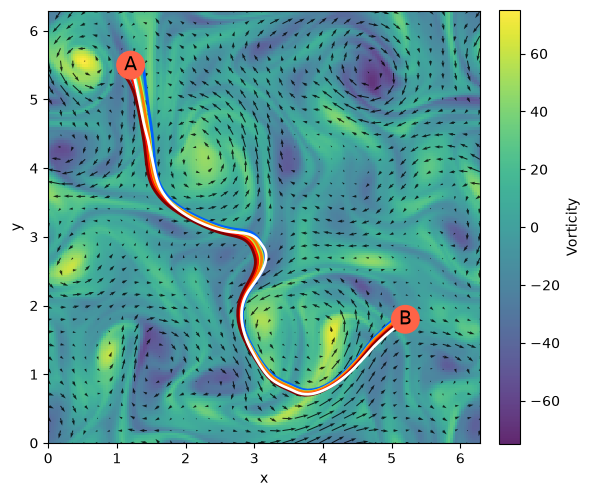

In [11]:
import h5py

env = ZermeloEnv(CFG, VelField)
results = evaluate_policy(model=best_policy, env=env, n_eval=5000)

success_probability = np.mean([r["success"] for r in results])
mean_success_time = np.mean([r["time"] for r in results if r["success"]])

print(f"Success probability : {success_probability:.4f}")
print(f"Mean success time: {mean_success_time:.4f}")

track_opt = []

with h5py.File("./data/opt-control.jld2", "r") as f:
    x_opt = f["x_sp1"]  # x_v, x2_v, x_sr, x_tg, x_sp1, x_sp2, x_tp1, x_tp2, x2_tp1, x2_tp2
    y_opt = f["y_sp1"]
    track_opt = np.stack((x_opt, y_opt), axis=1)

trajectories = [r["trajectory"] for r in results]
plot_trajectories(env, trajectories[0:10] + [track_opt], time=mean_success_time)

Success probability : 1.0000
Mean success time: 0.8058


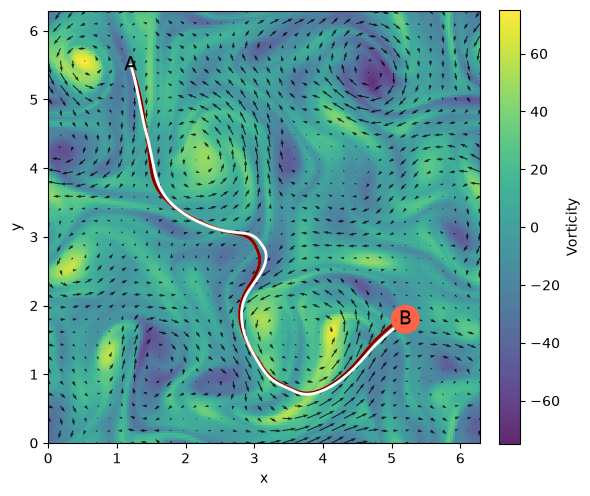

In [3]:
# exact starting position
CFG3 = TURB_STEADY_P1.copy()
CFG3["rA"]=0.0001
CFG3["rB"]=0.2

env3 = ZermeloEnv(CFG3, VelField)
results3 = evaluate_policy(model=best_policy, env=env3, n_eval=10)

success_probability3 = np.mean([r["success"] for r in results3])
mean_success_time3 = np.mean([r["time"] for r in results3 if r["success"]])

print(f"Success probability : {success_probability3:.4f}")
print(f"Mean success time: {mean_success_time3:.4f}")

trajectories3 = [r["trajectory"] for r in results3]
plot_trajectories(env3, trajectories3[0:10] + [track_opt], time=mean_success_time3)

# Problem Steady P2

In [4]:
CFG2 = TURB_STEADY_P2.copy()

env2 = ZermeloEnv(CFG2, VelField)
obs_dim = env2.observation_space.shape[0]
act_dim = env2.action_space.shape[0]
best_policy2 = PolicyNet(obs_dim, act_dim)
best_policy2.load_state_dict(torch.load("./saved_models/sp2.pth"))

<All keys matched successfully>

### Model Evaluation

Success probability : 1.0000
Mean success time: 0.7996


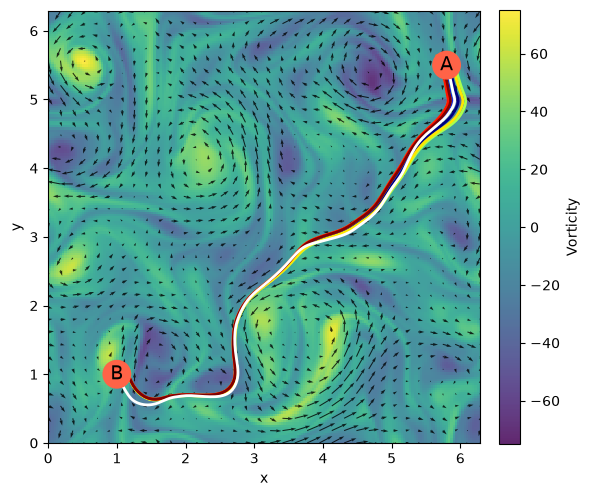

In [5]:
env2 = ZermeloEnv(CFG2, VelField)
results2 = evaluate_policy(model=best_policy2, env=env2, n_eval=5000)

success_probability2 = np.mean([r["success"] for r in results2])
mean_success_time2 = np.mean([r["time"] for r in results2 if r["success"]])

print(f"Success probability : {success_probability2:.4f}")
print(f"Mean success time: {mean_success_time2:.4f}")

track2_opt = []

with h5py.File("./data/opt-control.jld2", "r") as f:
    x2_opt = f["x_sp2"]  # x_v, x2_v, x_sr, x_tg, x_sp1, x_sp2, x_tp1, x_tp2, x2_tp1, x2_tp2
    y2_opt = f["y_sp2"]
    track2_opt = np.stack((x2_opt, y2_opt), axis=1)

trajectories2 = [r["trajectory"] for r in results2]
plot_trajectories(env2, trajectories2[0:10] + [track2_opt], time=mean_success_time2)

Success probability : 1.0000
Mean success time: 0.7988


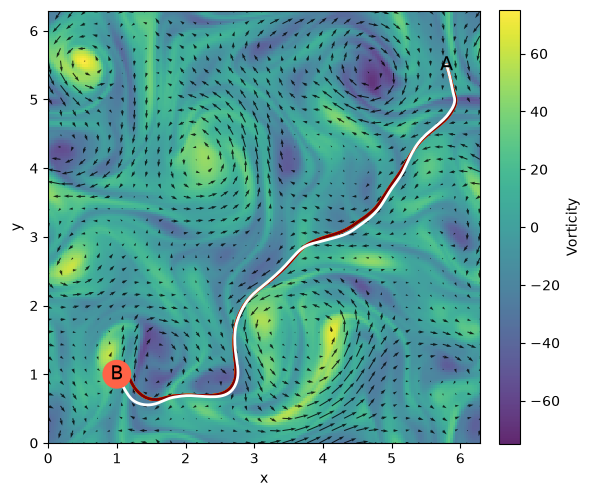

In [6]:
# exact starting position
CFG4 = TURB_STEADY_P2.copy()
CFG4["rA"]=0.0001
CFG4["rB"]=0.2

env4 = ZermeloEnv(CFG4, VelField)
results4 = evaluate_policy(model=best_policy2, env=env4, n_eval=10)

success_probability4 = np.mean([r["success"] for r in results4])
mean_success_time4 = np.mean([r["time"] for r in results4 if r["success"]])

print(f"Success probability : {success_probability4:.4f}")
print(f"Mean success time: {mean_success_time4:.4f}")

trajectories4 = [r["trajectory"] for r in results4]
plot_trajectories(env4, trajectories4[0:10] + [track2_opt], time=mean_success_time4)

# Figure 5

In [7]:
import numpy as np
import matplotlib.pyplot as plt


def plot_figure_5(env, env2, trajectories_A, trajectories_B, time_A, time_B, n_vort=200, n_vel=36, cmap="viridis"):
    fig, axes = plt.subplots(1, 2, figsize=(13.4, 6), constrained_layout=True)

    def plot_panel_A(ax):
        
        # Vorticity field
        x = np.linspace(env.x_min, env.x_max, n_vort)
        y = np.linspace(env.y_min, env.y_max, n_vort)
        X, Y = np.meshgrid(x, y)

        VORT = np.vectorize(env.vel_field.vort)(X, Y, time_A)
        vmax = np.max(np.abs(VORT))

        im = ax.pcolormesh(X, Y, VORT, shading="auto", cmap=cmap, vmin=-vmax, vmax=vmax, alpha=0.85, zorder=1, rasterized=True)

        # Colorbar
        #cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        #cbar.ax.tick_params(labelsize=12)

        # Velocity field
        xq = np.linspace(env.x_min, env.x_max, n_vel)
        yq = np.linspace(env.y_min, env.y_max, n_vel)
        Xq, Yq = np.meshgrid(xq, yq)

        U = np.vectorize(env.vel_field.velX)(Xq, Yq, time_A)
        V = np.vectorize(env.vel_field.velY)(Xq, Yq, time_A)

        ax.quiver(Xq, Yq, U, V, color="k", alpha=0.8, zorder=2, rasterized=True)

        # Trajectories
        colors = list(
            plt.cm.jet(
                np.linspace(0, 1, len(trajectories_A) - 1)
            )
        )
        colors.append("white")

        for traj, color in zip(trajectories_A, colors):
            ax.plot(traj[:, 0], traj[:, 1], lw=3.5, color=color, zorder=3)

        ax.add_patch(plt.Circle((env.xA, env.yA), env.rA, color="tomato", alpha=1, zorder=4))
        ax.add_patch(plt.Circle((env.xB, env.yB), env.rB, color="tomato", alpha=1, zorder=4))

        ax.text(env.xA, env.yA, "A", color="black", fontsize=20, ha="center", va="center", zorder=5)
        ax.text(env.xB, env.yB, "B", color="black", fontsize=20, ha="center", va="center", zorder=5)

        ax.text(0.15, 0.15, "P1", transform=ax.transAxes, fontsize=28, fontweight="bold", ha="center", va="center", color="white", zorder=10)

        # Formatting
        ax.set_xlim(env.x_min, env.x_max)
        ax.set_ylim(env.y_min, env.y_max)
        ax.set_aspect("equal")

        ax.set_xlabel("x", fontsize=32)
        ax.set_ylabel("y", fontsize=32)

        ax.set_xticks([0, 2, 4, 6])
        ax.set_yticks([0, 2, 4, 6])
        ax.tick_params(axis="both", which="major", labelsize=24)
        ax.grid(False)


    def plot_panel_B(ax):
        
        # Vorticity field
        x = np.linspace(env2.x_min, env2.x_max, n_vort)
        y = np.linspace(env2.y_min, env2.y_max, n_vort)
        X, Y = np.meshgrid(x, y)

        VORT = np.vectorize(env2.vel_field.vort)(X, Y, time_B)
        vmax = np.max(np.abs(VORT))

        im = ax.pcolormesh(X, Y, VORT, shading="auto", cmap=cmap, vmin=-vmax, vmax=vmax, alpha=0.85, zorder=1, rasterized=True)

        # Colorbar
        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label("vorticity", fontsize=28)
        cbar.set_ticks([-70, -35, 0, 35, 70])
        cbar.ax.tick_params(labelsize=20)

        # Velocity field
        xq = np.linspace(env2.x_min, env2.x_max, n_vel)
        yq = np.linspace(env2.y_min, env2.y_max, n_vel)
        Xq, Yq = np.meshgrid(xq, yq)

        U = np.vectorize(env2.vel_field.velX)(Xq, Yq, time_B)
        V = np.vectorize(env2.vel_field.velY)(Xq, Yq, time_B)

        ax.quiver(Xq, Yq, U, V, color="k", alpha=0.8, zorder=2, rasterized=True)

        # Trajectories
        colors = list(
            plt.cm.jet(
                np.linspace(0, 1, len(trajectories_B) - 1)
            )
        )
        colors.append("white")

        for traj, color in zip(trajectories_B, colors):
            ax.plot(traj[:, 0], traj[:, 1], lw=3.5, color=color, zorder=3)

        ax.add_patch(plt.Circle((env2.xA, env2.yA), env2.rA, color="tomato", alpha=1, zorder=4))
        ax.add_patch(plt.Circle((env2.xB, env2.yB), env2.rB, color="tomato", alpha=1, zorder=4))

        ax.text(env2.xA, env2.yA, "A", color="black", fontsize=20, ha="center", va="center", zorder=5)
        ax.text(env2.xB, env2.yB, "B", color="black", fontsize=20, ha="center", va="center", zorder=5)

        ax.text(0.82, 0.15, "P2", transform=ax.transAxes, fontsize=28, fontweight="bold", ha="center", va="center", color="white", zorder=10)

        # Formatting
        ax.set_xlim(env2.x_min, env2.x_max)
        ax.set_ylim(env2.y_min, env2.y_max)
        ax.set_aspect("equal")

        ax.set_xlabel("x", fontsize=32)
        #ax.set_ylabel("y", fontsize=18)

        ax.set_xticks([0, 2, 4, 6])
        ax.set_yticks([0, 2, 4, 6])
        ax.tick_params(axis="both", which="major", labelsize=24)
        ax.grid(False)

        
    # ---------------------------------------------------------
    # Plot panels A and B
    # ---------------------------------------------------------
    plot_panel_A(axes[0])
    plot_panel_B(axes[1])
    
    plt.savefig("./figures/fig5.pdf", format="pdf", bbox_inches="tight", dpi=300, pad_inches=0)

    plt.show()
    plt.close(fig)

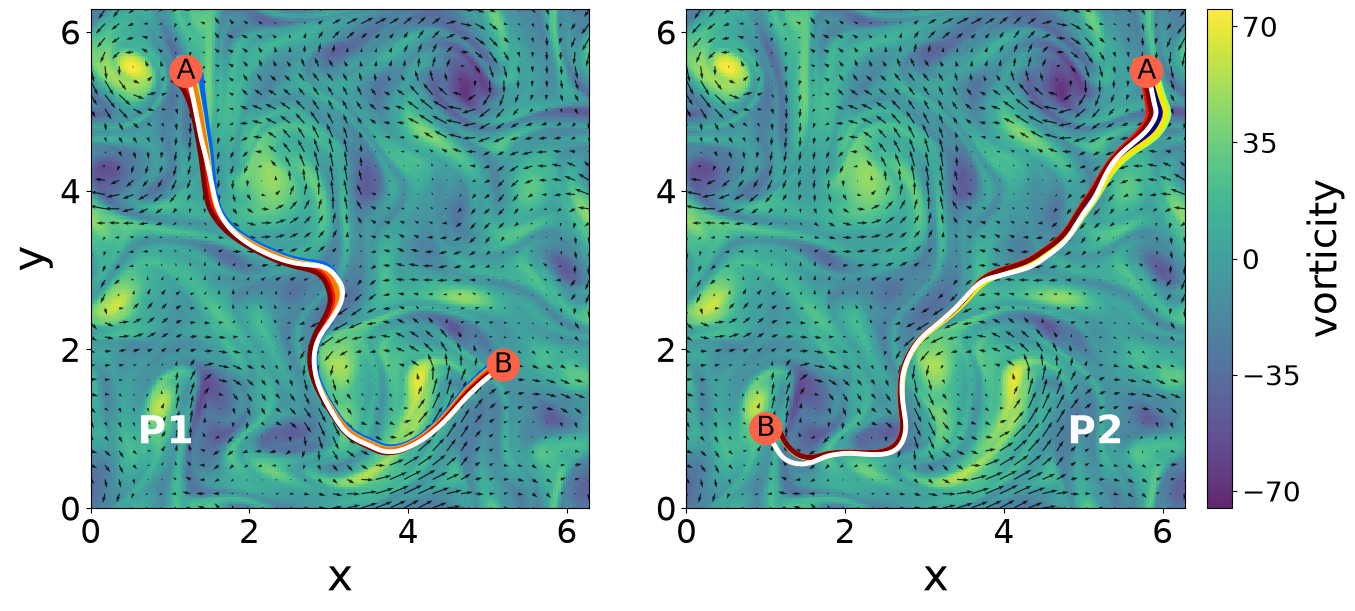

In [12]:
plot_figure_5(env, env2, trajectories[0:10] + [track_opt], trajectories2[0:10] + [track2_opt] , mean_success_time, mean_success_time2)

# Figure 6

In [9]:
def plot_figure_6(env, env2, policy_A, policy_B, track_A, track_B, n_vel=36, cmap="viridis"):
    fig, axes = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)

    def plot_panel_A(ax):        
        # Policy field
        xq = np.linspace(env.x_min, env.x_max, n_vel)
        yq = np.linspace(env.y_min, env.y_max, n_vel)
        Xq, Yq = np.meshgrid(xq, yq)

        positions = np.stack([Xq.ravel(), Yq.ravel()], axis=1)
        obs = torch.tensor(positions, dtype=torch.float32)

        with torch.no_grad():
            theta = policy_A(obs)

        theta = theta.squeeze(-1).cpu().numpy()
        theta = theta.reshape(Xq.shape)

        U = np.cos(theta)
        V = np.sin(theta)

        ax.set_facecolor(plt.cm.viridis(0.75))
        ax.streamplot(Xq, Yq, U, V, color="white", density=2.0, linewidth=1.2, arrowsize=1.5, zorder=2)

        ax.plot(track_A[:, 0], track_A[:, 1], lw=3.5, color="tomato", zorder=3)

        ax.add_patch(plt.Circle((env.xA, env.yA), env.rA, color="tomato", alpha=1, zorder=4))
        ax.add_patch(plt.Circle((env.xB, env.yB), env.rB, color="tomato", alpha=1, zorder=4))

        ax.text(env.xA, env.yA, "A", color="black", fontsize=20, ha="center", va="center", zorder=5)
        ax.text(env.xB, env.yB, "B", color="black", fontsize=20, ha="center", va="center", zorder=5)

        ax.text(0.15, 0.15, "P1", transform=ax.transAxes, fontsize=28, fontweight="bold", ha="center", va="center", color="darkblue", zorder=10)

        # Formatting
        ax.set_xlim(env.x_min, env.x_max)
        ax.set_ylim(env.y_min, env.y_max)
        ax.set_aspect("equal")

        ax.set_xlabel("x", fontsize=32)
        ax.set_ylabel("y", fontsize=32)

        ax.set_xticks([0, 2, 4, 6])
        ax.set_yticks([0, 2, 4, 6])
        ax.tick_params(axis="both", which="major", labelsize=24)
        ax.grid(False)


    def plot_panel_B(ax):

        # Velocity field
        xq = np.linspace(env2.x_min, env2.x_max, n_vel)
        yq = np.linspace(env2.y_min, env2.y_max, n_vel)
        Xq, Yq = np.meshgrid(xq, yq)

        positions = np.stack([Xq.ravel(), Yq.ravel()], axis=1)
        obs = torch.tensor(positions, dtype=torch.float32)

        with torch.no_grad():
            theta = policy_B(obs)

        theta = theta.squeeze(-1).cpu().numpy()
        theta = theta.reshape(Xq.shape)

        U = np.cos(theta)
        V = np.sin(theta)

        ax.set_facecolor(plt.cm.viridis(0.75))
        ax.streamplot(Xq, Yq, U, V, color="white", density=2.0, linewidth=1.2, arrowsize=1.5, zorder=2)

        ax.plot(track_B[:, 0], track_B[:, 1], lw=2.5, color="tomato", zorder=3)

        ax.add_patch(plt.Circle((env2.xA, env2.yA), env2.rA, color="tomato", alpha=1, zorder=4))
        ax.add_patch(plt.Circle((env2.xB, env2.yB), env2.rB, color="tomato", alpha=1, zorder=4))

        ax.text(env2.xA, env2.yA, "A", color="black", fontsize=20, ha="center", va="center", zorder=5)
        ax.text(env2.xB, env2.yB, "B", color="black", fontsize=20, ha="center", va="center", zorder=5)

        ax.text(0.82, 0.15, "P2", transform=ax.transAxes, fontsize=28, fontweight="bold", ha="center", va="center", color="darkblue", zorder=10)

        # Formatting
        ax.set_xlim(env2.x_min, env2.x_max)
        ax.set_ylim(env2.y_min, env2.y_max)
        ax.set_aspect("equal")

        ax.set_xlabel("x", fontsize=32)
        #ax.set_ylabel("y", fontsize=18)

        ax.set_xticks([0, 2, 4, 6])
        ax.set_yticks([0, 2, 4, 6])
        ax.tick_params(axis="both", which="major", labelsize=24)
        ax.grid(False)

        
    # ---------------------------------------------------------
    # Plot panels A and B
    # ---------------------------------------------------------
    plot_panel_A(axes[0])
    plot_panel_B(axes[1])
    
    plt.savefig("./figures/fig6.pdf", format="pdf", bbox_inches="tight", dpi=300, pad_inches=0)

    plt.show()
    plt.close(fig)

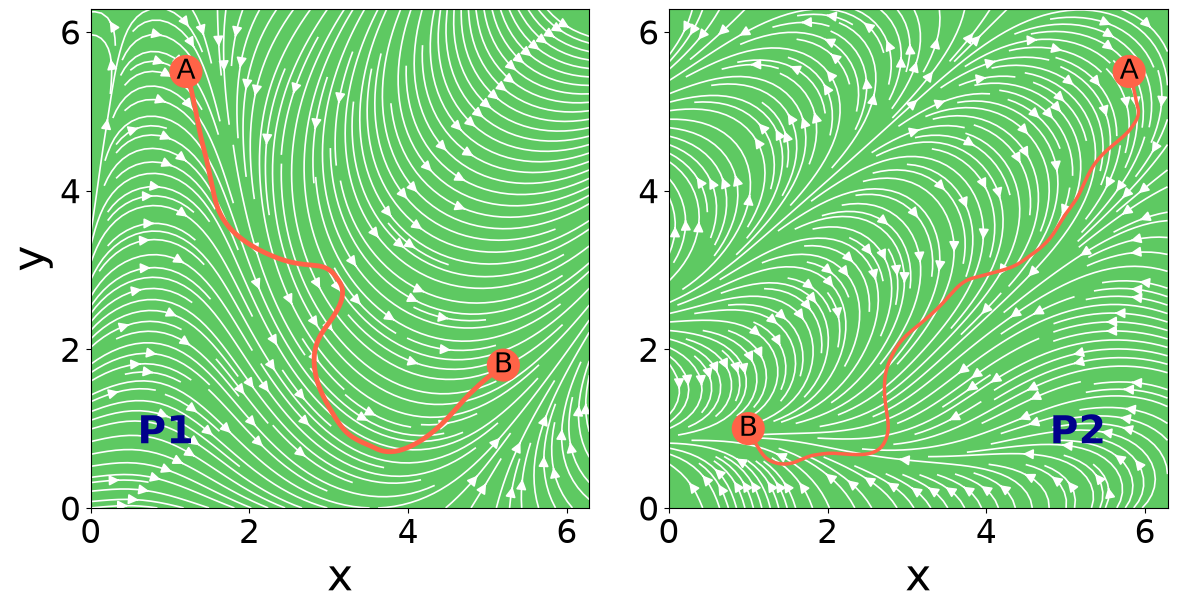

In [10]:
plot_figure_6(env, env2, best_policy, best_policy2, track_opt, track2_opt, n_vel=36, cmap="viridis")